# 01 — PMSM Machine Model + Current Controllers (real θ/ω feedback)

**Stage 1** of the sensorless-drive build (see `PLAN.md` and `PMSM_Sensorless_Model_Spec.pdf`
for the full derivation and block diagrams).

This notebook implements:
- the PMSM electromagnetic + mechanical plant in the **dq frame** (power-invariant, motor
  convention),
- **dq PI current controllers** (separate gains per axis, technical-optimum tuning against
  the inverter delay τu) with EMF feedforward decoupling and voltage saturation,
- a **quadratic fan load**,
- a torque-command schedule `[0, 10, 30, 50, 70, 10, 70, -20, 50]` N·m, run to convergence
  at each level.

The controller uses the plant's **own real** θr/ωmech — no observer yet (that's notebook 02).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pmsm_common as pc

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Parameters

All machine/controller/load constants live in `pmsm_common.py` (single source of truth shared by all three notebooks).

In [2]:
p = pc.make_params()

print(f"Rs={p.Rs*1e3:.1f} mOhm  Ld={p.Ld*1e6:.1f} uH  Lq={p.Lq*1e6:.1f} uH  "
      f"psi_m={p.psi_m:.4f} Wb  psi_m_pi={p.psi_m_pi:.5f} Wb  p={p.p}")
print(f"J={p.J} kg m^2  B={p.B}  k_fan={p.k_fan:.4e} N m/(rad/s)^2")
print(f"tau_u={p.tau_u*1e6:.0f} us -> Kp_d={p.Kp_d:.3f} Ki_d={p.Ki_d:.1f}  "
      f"Kp_q={p.Kp_q:.3f} Ki_q={p.Ki_q:.1f}")
print(f"Vmax={p.Vmax} V")
print(f"Rated: {pc.P_rated/1e3:.1f} kW @ {pc.n_rated_rpm:.0f} rpm -> "
      f"omega_mech_rated={pc.omega_mech_rated:.2f} rad/s, T_rated={pc.T_rated:.2f} N*m")

Rs=18.0 mOhm  Ld=180.0 uH  Lq=176.0 uH  psi_m=0.0530 Wb  psi_m_pi=0.06491 Wb  p=10
J=0.05 kg m^2  B=0.0  k_fan=2.8381e-03 N m/(rad/s)^2
tau_u=10 us -> Kp_d=9.000 Ki_d=900.0  Kp_q=8.800 Ki_q=900.0
Vmax=600.0 V
Rated: 11.0 kW @ 1500 rpm -> omega_mech_rated=157.08 rad/s, T_rated=70.03 N*m


## 2. Plant + controller right-hand side

Fixed state layout (see `pmsm_common.py` docstring): `x = [isd, isq, omega_mech, theta_r, xi_d, xi_q]`,
where `xi_d, xi_q` are the PI integrators (i.e. `xi_d(t) = \int Ki_d \cdot (id^*-isd)\,dt`, so the
controller output is simply `Kp*(err) + xi + feedforward`).

Everything (references, gains, feedforward, saturation+anti-windup, plant, load) is written out
explicitly here per PLAN.md — nothing is hidden in `pmsm_common.py` beyond constants/formulas.

In [3]:
def rhs_nb1(t, x, p):
    isd, isq, omega_mech, theta_r, xi_d, xi_q = x
    omega_r = p.p * omega_mech                      # electrical speed

    # --- current errors (real feedback: the plant's own isd, isq) ---
    err_d = p.isd_ref - isd
    err_q = p.isq_ref - isq

    # --- EMF feedforward decoupling (real omega_r) ---
    ff_d = -omega_r * p.Lq * isq
    ff_q = omega_r * p.Ld * isd + omega_r * p.psi_m_pi

    # --- PI controller (xi already IS the integral term) + feedforward ---
    usd_unsat = p.Kp_d * err_d + xi_d + ff_d
    usq_unsat = p.Kp_q * err_q + xi_q + ff_q

    # --- voltage saturation + back-calculation anti-windup ---
    usd, usq, _sat = pc.saturate_voltage(usd_unsat, usq_unsat, p.Vmax)
    dxi_d = p.Ki_d * err_d + pc.antiwindup_term(usd_unsat, usd, p.Kp_d)
    dxi_q = p.Ki_q * err_q + pc.antiwindup_term(usq_unsat, usq, p.Kp_q)

    # --- plant electrical equations ---
    disd = (usd - p.Rs * isd + omega_r * p.Lq * isq) / p.Ld
    disq = (usq - p.Rs * isq - omega_r * p.Ld * isd - omega_r * p.psi_m_pi) / p.Lq

    # --- torque + mechanical equation (quadratic fan load) ---
    Te = p.p * p.psi_m_pi * isq + p.p * (p.Ld - p.Lq) * isd * isq
    T_load = p.k_fan * omega_mech * abs(omega_mech)
    domega_mech = (Te - T_load - p.B * omega_mech) / p.J

    dtheta_r = omega_r

    return [disd, disq, domega_mech, dtheta_r, dxi_d, dxi_q]

## 3. Torque-command schedule simulation

Run each torque level to convergence via `pmsm_common.simulate_schedule` (chunked adaptive RK45 + convergence check on |dω/dt| and |iq-iq_ref|).

In [4]:
torque_levels = [0, 10, 30, 50, 70, 10, 70, -20, 50]

x0 = np.zeros(6)
p = pc.make_params()

import time
t0 = time.time()
result = pc.simulate_schedule(rhs_nb1, x0, p, torque_levels)
print(f"simulated {result.t[-1]:.3f} s of drive time in {time.time()-t0:.1f} s wall-clock, "
      f"{result.t.size} samples")
print("converged per level:", result.converged_flags)

simulated 5.845 s of drive time in 5.2 s wall-clock, 89161 samples
converged per level: [True, True, True, True, True, True, True, True, True]


## 4. Results

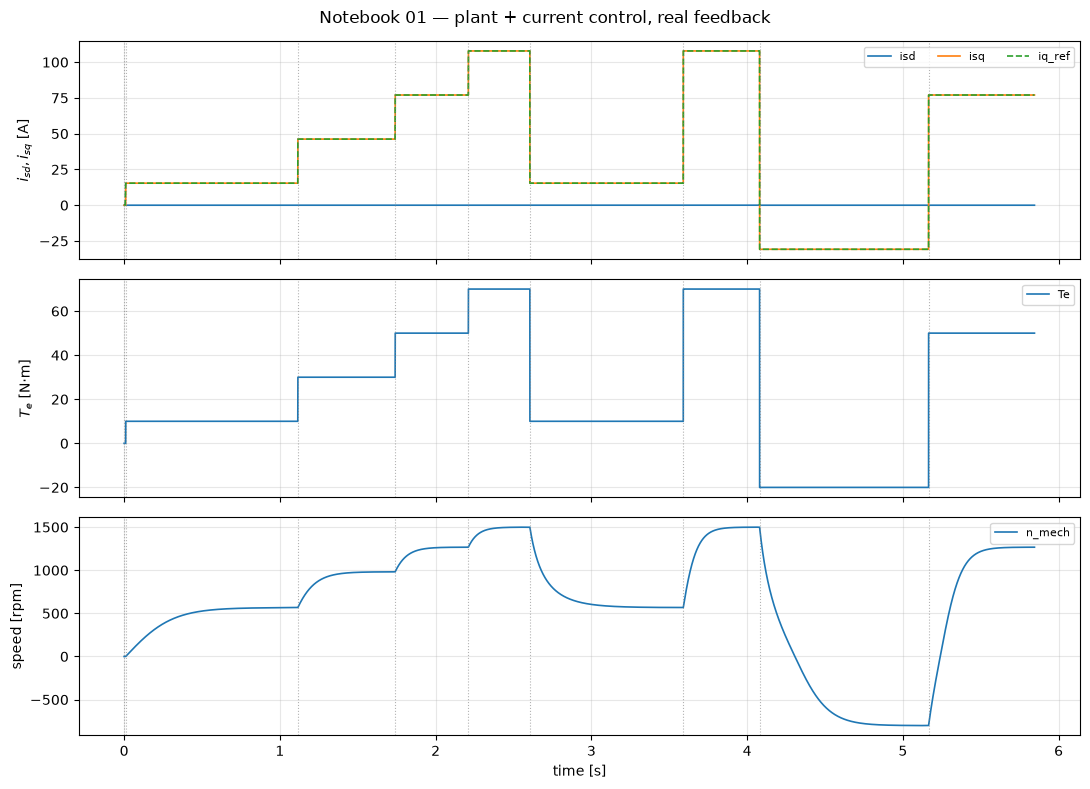

In [5]:
t = result.t
X = result.X
isd, isq, omega_mech, theta_r = X[0], X[1], X[2], X[3]

# reconstruct iq_ref(t) and Te(t) for plotting
level_times = result.level_times
level_values = result.level_values
iq_ref_t = np.piecewise(
    t, [t >= lt for lt in level_times],
    [v / (p.p * p.psi_m_pi) for v in level_values]
)
Te = p.p * p.psi_m_pi * isq + p.p * (p.Ld - p.Lq) * isd * isq
n_rpm = omega_mech * 60 / (2 * np.pi)

fig, axes = pc.plot_traces(
    t,
    {
        r"$i_{sd},i_{sq}$ [A]": [("isd", isd), ("isq", isq), ("iq_ref", iq_ref_t, "--")],
        r"$T_e$ [N·m]": [("Te", Te)],
        "speed [rpm]": [("n_mech", n_rpm)],
    },
    level_times=level_times,
    title="Notebook 01 — plant + current control, real feedback",
)

## 5. Sanity checks

- Current-loop response: after each step, `iq` should settle onto `iq_ref` with a closed-loop
  time constant on the order of `2*tau_u = 20 us` (far faster than anything visible at this
  plot's timescale — that's the point of the technical-optimum tuning).
- Mechanical equilibrium: at each level, steady state should satisfy `Te ≈ k_fan*omega*|omega|`
  (fan load balances the commanded torque). Check below, including the `-20` N·m reversal.

In [6]:
print(f"{'Tref':>6} {'omega_eq (rad/s)':>18} {'n_eq (rpm)':>12} {'k*w|w| check (N*m)':>20}")
for lt, lv in zip(level_times, level_values):
    # last sample of each level: find index just before the next level starts
    idx = np.searchsorted(t, lt, side="right")
    # take a sample near the end of that level's window
    next_lt = level_times[level_times.index(lt) + 1] if lt != level_times[-1] else t[-1]
    end_idx = np.searchsorted(t, next_lt, side="left") - 1
    w_eq = omega_mech[end_idx]
    print(f"{lv:6.0f} {w_eq:18.3f} {w_eq*60/(2*np.pi):12.2f} {p.k_fan*w_eq*abs(w_eq):20.3f}")

  Tref   omega_eq (rad/s)   n_eq (rpm)   k*w|w| check (N*m)
     0              0.000         0.00                0.000
    10             59.289       566.17                9.977
    30            102.775       981.42               29.978
    50            132.701      1267.21               49.979
    70            157.025      1499.48               69.979
    10             59.429       567.50               10.024
    70            157.025      1499.48               69.980
   -20            -83.899      -801.17              -19.978
    50            132.701      1267.20               49.978


## Next

`02_pmsm_with_parallel_observer.ipynb` adds the αβ Structure-B back-EMF observer + PLL,
running in parallel and fed by the real θr (no mismatch yet) — purely to validate the
observer's own tuning before it's trusted to close the loop in notebook 03.